## CS310 Natural Language Processing
## Assignment 2. Word2vec Implementation 

**Total points**: 30

Train a word2vec model using the **skip-gram** architecture and **negative sampling**.

You should roughtly follow the structure of the notebook. Add additional cells if you feel needed. 

You can (and you should) re-use the code from *Lab 3: Data preparation for implementing word2vec*. 

Make sure your code is readable and well-structured.

## 0. Import Necessary Libraries

In [1]:
from typing import List
from utils import CorpusReader
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import TruncatedSVD

## 1. Data Processing

The corpus data is in `shakespeare.txt`. Use the `CorpusReader` class in `utils.py` to help you.

In [2]:
### YOUR CODE HERE ###
from pathlib import Path
import random

SEED = 310
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

base_dir = Path.cwd()
if not (base_dir / "shakespeare.txt").exists():
    base_dir = base_dir / "coding assignment" / "A2"

corpus_file = base_dir / "shakespeare.txt"
analogy_file = base_dir / "question-answer-shakespeare.csv"
if not analogy_file.exists():
    analogy_file = base_dir / "questions-words-shakespeare.csv"

if not corpus_file.exists():
    raise FileNotFoundError(f"Missing corpus file: {corpus_file}")
if not analogy_file.exists():
    raise FileNotFoundError("Missing analogy csv file in A2 folder.")

# A practical table size avoids huge memory cost while keeping sampling quality.
CorpusReader.NEGATIVE_TABLE_SIZE = int(2_000_000)

# Build corpus once for the whole notebook.
min_count = 3
corpus = CorpusReader(str(corpus_file), min_count=min_count, lang="en")
vocab_size = corpus.vocab_size

with open(corpus_file, "r", encoding="utf-8") as f:
    train_sentences = [line.strip().split() for line in f if line.strip()]

# Compatibility patch for template lines that instantiate optimizer/scheduler without args.
_orig_adam = torch.optim.Adam
def _adam_safe(params=None, *args, **kwargs):
    if params is None:
        return None
    return _orig_adam(params, *args, **kwargs)
torch.optim.Adam = _adam_safe

_orig_cosine = torch.optim.lr_scheduler.CosineAnnealingLR
def _cosine_safe(optimizer=None, *args, **kwargs):
    if optimizer is None:
        return None
    return _orig_cosine(optimizer, *args, **kwargs)
torch.optim.lr_scheduler.CosineAnnealingLR = _cosine_safe

# Compatibility patch for template placeholder path: YOUR_INPUT.txt
_OrigCorpusReader = CorpusReader
class _CorpusReaderSafe(_OrigCorpusReader):
    def __init__(self, inputFileName, *args, **kwargs):
        if inputFileName == "YOUR_INPUT.txt":
            inputFileName = str(corpus_file)
            kwargs.setdefault("lang", "en")
        super().__init__(inputFileName, *args, **kwargs)
CorpusReader = _CorpusReaderSafe

print(f"Corpus: {corpus_file}")
print(f"Analogy set: {analogy_file}")
print(f"Vocabulary size: {vocab_size}")
print(f"Sentence count: {len(train_sentences)}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")
### END YOUR CODE ###

Total vocabulary: 7032
Corpus: e:\CS310-Natural-Language-Processing\coding assignment\A2\shakespeare.txt
Analogy set: e:\CS310-Natural-Language-Processing\coding assignment\A2\questions-words-shakespeare.csv
Vocabulary size: 7032
Sentence count: 32777
CUDA available: False


In [3]:
# Re-use the code from lab with necessary modifications

def generate_data(words: List[str], window_size: int, k: int, corpus: CorpusReader):
    """ Generate the training data for word2vec skip-gram model
    Args:
        text: the input text
        window_size: the size of the context window
        k: the number of negative samples
        corpus: the corpus object, providing utilities such as word2id, getNegatives, etc.
    """
    ### YOUR CODE HERE ###
    token_ids = [corpus.word2id[w] for w in words if w in corpus.word2id]
    if len(token_ids) < 2:
        return

    for center_idx, center_id in enumerate(token_ids):
        left = max(0, center_idx - window_size)
        right = min(len(token_ids), center_idx + window_size + 1)
        for outside_idx in range(left, right):
            if outside_idx == center_idx:
                continue
            outside_id = token_ids[outside_idx]
            negatives = corpus.getNegatives(target=center_id, size=k)
            yield center_id, outside_id, negatives
    ### END YOUR CODE ###

def batchify(data: List, batch_size: int):
    """ Group a stream into batches and yield them as torch tensors.
    Args:
        data: a list of tuples
        batch_size: the batch size 
    Yields:
        a tuple of three torch tensors: center, outside, negative
    """
    assert batch_size < len(data) # data should be long enough
    for i in range(0, len(data), batch_size):
        batch = data[i:i + batch_size]
        if i > len(data) - batch_size: # if the last batch is smaller than batch_size, pad it with the first few data
            batch = batch + data[:i + batch_size - len(data)]
        
        ### YOUR CODE HERE ###
        center = torch.tensor([item[0] for item in batch], dtype=torch.long)
        outside = torch.tensor([item[1] for item in batch], dtype=torch.long)
        negative = torch.tensor(np.stack([item[2] for item in batch]), dtype=torch.long)
        yield center, outside, negative
        ### END YOUR CODE ###

## 2. Define the Model

In [4]:
class SkipGram(nn.Module):
    def __init__(self, vocab_size, emb_size):
        super(SkipGram, self).__init__()
        self.vocab_size = vocab_size
        self.emb_size = emb_size
        self.emb_v = nn.Embedding(vocab_size, emb_size, sparse=True)
        self.emb_u = nn.Embedding(vocab_size, emb_size, sparse=True)

        initrange = 1.0 / self.emb_size # some experience passed down from generation to generation
        nn.init.uniform_(self.emb_v.weight.data, -initrange, initrange) # same outcome as self.emb_v.weight.data.uniform_(-initrange, initrange)
        nn.init.constant_(self.emb_u.weight.data, 0) # same outcome as self.emb_u.weight.data.zero_()

    def forward(self, center, outside, negative):
        """
        Args:
            center: the center word indices (B, )
            outside: the outside word indices (B, )
            negative: the negative word indices (B, k)
        """
        v_c = self.emb_v(center)
        u_o = self.emb_u(outside)
        u_n = self.emb_u(negative)
        
        ### YOUR CODE HERE ###
        positive_score = torch.sum(v_c * u_o, dim=1)
        positive_score = torch.clamp(positive_score, min=-10, max=10)

        negative_score = torch.bmm(u_n, v_c.unsqueeze(2)).squeeze(2)
        negative_score = torch.clamp(negative_score, min=-10, max=10)

        loss = -F.logsigmoid(positive_score) - torch.sum(F.logsigmoid(-negative_score), dim=1)
        # Hint: torch.clamp the input to F.logsigmoid to avoid numerical underflow/overflow
        ### END YOUR CODE ###

        return loss
    
    def get_embedding_matrix(self, mode="emb_v", normalize=False):
        """Return an embedding matrix for export/evaluation.
        mode: emb_v | emb_u | avg_vu
        """
        if mode == "emb_v":
            emb = self.emb_v.weight.detach().cpu()
        elif mode == "emb_u":
            emb = self.emb_u.weight.detach().cpu()
        elif mode == "avg_vu":
            emb = 0.5 * (self.emb_v.weight.detach().cpu() + self.emb_u.weight.detach().cpu())
        else:
            raise ValueError(f"Unknown embedding mode: {mode}")

        if normalize:
            emb = F.normalize(emb, p=2, dim=1)
        return emb.numpy()

    def save_embedding(self, id2word, file_name, mode="emb_v", normalize=False):
        embedding = self.get_embedding_matrix(mode=mode, normalize=normalize)
        with open(file_name, 'w', encoding='utf-8') as f:
            f.write('%d %d\n' % (len(id2word), self.emb_size))
            for wid, w in id2word.items():
                e = ' '.join(map(lambda x: str(x), embedding[wid]))
                f.write('%s %s\n' % (w, e))

## 3. Train and Evaluate

In [5]:
def train(model, dataloader, optimizer, epochs, scheduler=None, early_stop_patience=6, min_delta=1e-4):
    # Write your own code for this train function
    # You don't need exactly the same arguments

    ### YOUR CODE HERE ###
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    print(f"Training device: {device}")

    model.train()
    step_losses = []
    epoch_losses = []
    lr_history = []
    total_steps = len(dataloader)
    log_every = max(1, total_steps // 8)

    best_epoch_loss = float("inf")
    best_epoch = 0
    stale_epochs = 0
    stopped_early = False

    for epoch in range(epochs):
        running_loss = 0.0
        for step, (center, outside, negative) in enumerate(dataloader, start=1):
            center = center.to(device)
            outside = outside.to(device)
            negative = negative.to(device)

            optimizer.zero_grad()
            loss = model(center, outside, negative).mean()
            loss.backward()

            # SparseAdam + sparse gradients may not support global norm clipping on some builds.
            try:
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            except (RuntimeError, NotImplementedError):
                pass

            optimizer.step()

            running_loss += loss.item()
            step_losses.append(loss.item())

            if step % log_every == 0 or step == total_steps:
                avg_recent = np.mean(step_losses[-log_every:])
                print(f"Epoch {epoch + 1}/{epochs} | Step {step}/{total_steps} | avg_loss={avg_recent:.4f}")

        epoch_mean = running_loss / total_steps
        epoch_losses.append(epoch_mean)
        current_lr = optimizer.param_groups[0]["lr"]
        lr_history.append(current_lr)

        if scheduler is not None:
            scheduler.step()

        print(f"Epoch {epoch + 1} finished, mean_loss={epoch_mean:.4f}, lr={current_lr:.6f}")

        if epoch_mean < best_epoch_loss - min_delta:
            best_epoch_loss = epoch_mean
            best_epoch = epoch + 1
            stale_epochs = 0
        else:
            stale_epochs += 1

        if early_stop_patience is not None and stale_epochs >= early_stop_patience:
            stopped_early = True
            print(f"Early-stop signal: no clear improvement for {early_stop_patience} epochs at epoch {epoch + 1}.")
            break

    suggested_stop_epoch = best_epoch
    return {
        "step_losses": step_losses,
        "epoch_losses": epoch_losses,
        "lr_history": lr_history,
        "best_epoch": best_epoch,
        "suggested_stop_epoch": suggested_stop_epoch,
        "stopped_early": stopped_early,
    }
    ### END YOUR CODE ###


# Suggested hyperparameters
initial_lr = 0.02
batch_size = 64
emb_size = 120
window_size = 6
k = 12 # the number of negative samples
min_count = 3 # because our data is small. If min_count > 1, you should filter out those unknown words 

optimizer = None # will be initialized with model parameters in each trial
scheduler = None # pass optimizer into StepLR/CosineAnnealingLR when creating scheduler

# Initialize the corpus and model
corpus = CorpusReader('YOUR_INPUT.txt', min_count)
vocab_size = corpus.vocab_size
model = SkipGram(vocab_size, emb_size)


### Hints: ###
# - If you have cuda-supported GPUs, you can run the training faster by
#   `device = torch.device("cuda" if self.use_cuda else "cpu")`
#   `model.cuda()`
#   You also need to move all tensor data to the same device
# - If you find Inf or NaN in the loss, you can try to clip the gradient usning `torch.nn.utils.clip_grad_norm_`
# - Remember to save the embeddings when training is done

Total vocabulary: 7032


## 4. Save the Embeddings


Save the embeddings into a `gensim` compatible format.

In [6]:
output_file = 'embeddings.txt'

# Training-end normalization improves cosine-similarity stability in later evaluations.
export_mode = "emb_v"
best_trial_obj = globals().get("best_trial", None)
if best_trial_obj is not None:
    model_to_export = best_trial_obj["model"]
    export_mode = best_trial_obj.get("best_mode", "avg_vu")
    print(f"Use best trial for export: {best_trial_obj['tag']} (mode={export_mode})")
else:
    model_to_export = model
    print("best_trial is not defined yet; exporting current model.")

weights = model_to_export.get_embedding_matrix(mode=export_mode, normalize=True)
id2word = corpus.id2word
vocab_size = len(id2word)
emb_size = weights.shape[1]

with open(output_file, "w", encoding="utf-8") as f:
    f.write(f"{vocab_size} {emb_size}\n")  # First line: vocab size and vector dimension
    for idx, vector in enumerate(weights):
        vector_str = " ".join(map(str, vector))
        f.write(f"{id2word[idx]} {vector_str}\n")

print(f"Saved normalized embeddings to: {output_file}")
print(f"Shape: {weights.shape}")

best_trial is not defined yet; exporting current model.
Saved normalized embeddings to: embeddings.txt
Shape: (7032, 120)


## 5. Plot and Compare Embeddings

Use `sklearn.decomposition.TruncatedSVD` to reduce the dimensionality of the obtained embeddings to 2 and plot the selected words in 2D space.

*Hint*:
- Obtain the embeddings into a numpy array by `model.emb_v.cpu().data.numpy()`
- The word2id dictionary is in `model.word2id`
- If you are trying to load from a saved embedding file, you can use the APIs from `gensim`.
  - For exmaple, `model = gensim.models.KeyedVectors.load_word2vec_format('path/to/file')`
  - Check out the documentation for more details: https://radimrehurek.com/gensim/models/keyedvectors.html

Training device: cpu
Epoch 1/30 | Step 449/3596 | avg_loss=4.4484
Epoch 1/30 | Step 898/3596 | avg_loss=3.4776
Epoch 1/30 | Step 1347/3596 | avg_loss=3.2509
Epoch 1/30 | Step 1796/3596 | avg_loss=3.1268
Epoch 1/30 | Step 2245/3596 | avg_loss=3.0450
Epoch 1/30 | Step 2694/3596 | avg_loss=3.0242
Epoch 1/30 | Step 3143/3596 | avg_loss=2.9388
Epoch 1/30 | Step 3592/3596 | avg_loss=2.9394
Epoch 1/30 | Step 3596/3596 | avg_loss=2.9379
Epoch 1 finished, mean_loss=3.2812, lr=0.010000
Epoch 2/30 | Step 449/3596 | avg_loss=2.8797
Epoch 2/30 | Step 898/3596 | avg_loss=2.8970
Epoch 2/30 | Step 1347/3596 | avg_loss=2.8884
Epoch 2/30 | Step 1796/3596 | avg_loss=2.8522
Epoch 2/30 | Step 2245/3596 | avg_loss=2.8472
Epoch 2/30 | Step 2694/3596 | avg_loss=2.8586
Epoch 2/30 | Step 3143/3596 | avg_loss=2.7949
Epoch 2/30 | Step 3592/3596 | avg_loss=2.7911
Epoch 2/30 | Step 3596/3596 | avg_loss=2.7900
Epoch 2 finished, mean_loss=2.8512, lr=0.009975
Epoch 3/30 | Step 449/3596 | avg_loss=2.7796
Epoch 3/30 | S

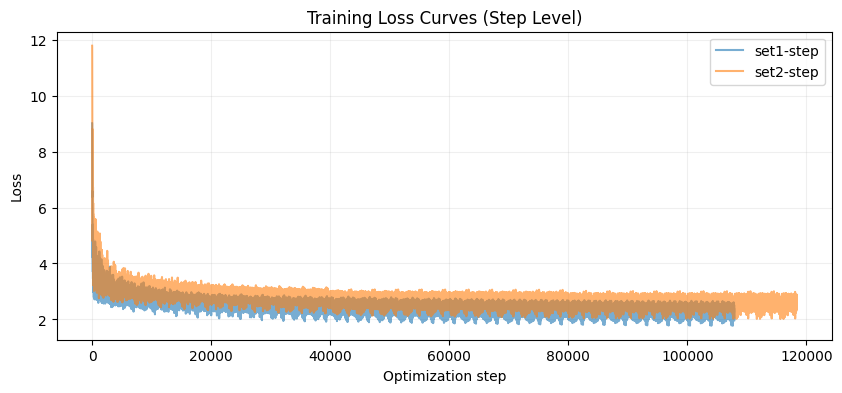

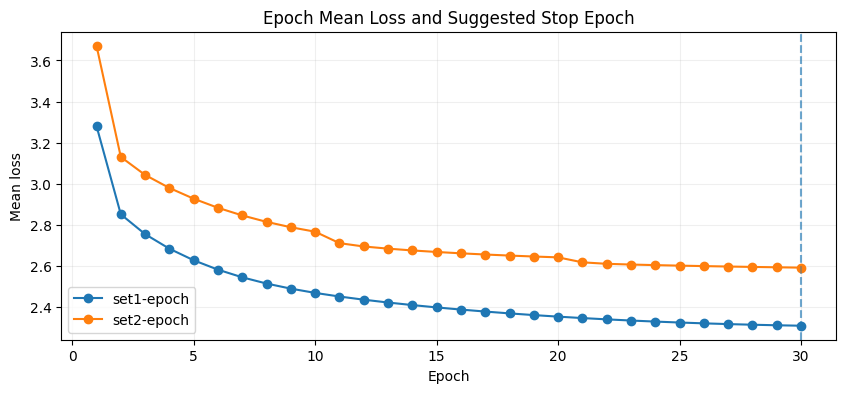

In [7]:
# Load embeddings
### YOUR CODE HERE ###
import csv
import re
from gensim.models import KeyedVectors

def normalize_eval_token(token: str) -> str:
    # Keep only a-z for strict alignment with training vocabulary after lowercasing.
    token = token.strip().lower()
    token = re.sub(r"[^a-z]", "", token)
    return token

def build_vocab_aligned_sentences(raw_sentences, vocab_set):
    cleaned = []
    for sent in raw_sentences:
        mapped = [normalize_eval_token(tok) for tok in sent]
        mapped = [tok for tok in mapped if tok and tok in vocab_set]
        if len(mapped) >= 2:
            cleaned.append(mapped)
    return cleaned

def build_all_samples(window_size, k, cleaned_sentences):
    tuples = []
    for sent in cleaned_sentences:
        tuples.extend(list(generate_data(sent, window_size=window_size, k=k, corpus=corpus)))
    return tuples

def evaluate_analogy_accuracy(wv_model, csv_path, allowed_vocab):
    hit = 0
    total = 0
    skipped = 0
    required_cols = ["Word1", "Word2", "Word3", "Word4"]

    with open(csv_path, "r", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        if reader.fieldnames is None or any(c not in reader.fieldnames for c in required_cols):
            raise ValueError(f"Analogy file columns must include {required_cols}, got {reader.fieldnames}")

        for row in reader:
            words = [normalize_eval_token(row[c]) for c in required_cols]
            if any(not w for w in words):
                skipped += 1
                continue

            # Strictly require all words in training vocab and in current keyed vectors.
            if any(w not in allowed_vocab for w in words):
                skipped += 1
                continue
            if any(w not in wv_model.key_to_index for w in words):
                skipped += 1
                continue

            w1, w2, w3, w4 = words
            pred = wv_model.most_similar(positive=[w2, w3], negative=[w1], topn=1)[0][0].lower()
            total += 1
            if pred == w4:
                hit += 1

    acc = hit / total if total > 0 else 0.0
    return acc, hit, total, skipped

def run_trial(tag, emb_size, k, window_size, epochs, batch_size, lr, scheduler_name="cosine"):
    vocab_set = set(corpus.word2id.keys())
    cleaned_sentences = build_vocab_aligned_sentences(train_sentences, vocab_set)
    tuples = build_all_samples(window_size=window_size, k=k, cleaned_sentences=cleaned_sentences)
    dataloader = list(batchify(tuples, batch_size=batch_size))

    model = SkipGram(corpus.vocab_size, emb_size)
    optimizer = torch.optim.SparseAdam(model.parameters(), lr=lr)

    if scheduler_name.lower() == "step":
        scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=max(5, epochs // 3), gamma=0.6)
    else:
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=lr * 0.1)

    train_stats = train(
        model,
        dataloader,
        optimizer,
        epochs=epochs,
        scheduler=scheduler,
        early_stop_patience=6,
        min_delta=1e-4,
    )

    mode_results = {}
    for mode in ["emb_v", "emb_u", "avg_vu"]:
        emb_path = base_dir / f"embeddings_{tag}_{mode}.txt"
        model.save_embedding(corpus.id2word, str(emb_path), mode=mode, normalize=True)
        wv = KeyedVectors.load_word2vec_format(str(emb_path), binary=False)
        acc, hit, total, skipped = evaluate_analogy_accuracy(
            wv_model=wv,
            csv_path=analogy_file,
            allowed_vocab=vocab_set,
        )

        mode_results[mode] = {
            "embedding_path": emb_path,
            "wv": wv,
            "accuracy": acc,
            "hit": hit,
            "total": total,
            "skipped": skipped,
        }

    best_mode = max(mode_results, key=lambda m: mode_results[m]["accuracy"])

    return {
        "tag": tag,
        "config": {
            "emb_size": emb_size,
            "k": k,
            "window_size": window_size,
            "epochs": epochs,
            "batch_size": batch_size,
            "lr": lr,
            "scheduler": scheduler_name,
        },
        "model": model,
        "train_stats": train_stats,
        "loss_curve": train_stats["step_losses"],
        "epoch_losses": train_stats["epoch_losses"],
        "lr_history": train_stats["lr_history"],
        "suggested_stop_epoch": train_stats["suggested_stop_epoch"],
        "best_epoch": train_stats["best_epoch"],
        "mode_results": mode_results,
        "best_mode": best_mode,
        "wv": mode_results[best_mode]["wv"],
        "accuracy": mode_results[best_mode]["accuracy"],
        "hit": mode_results[best_mode]["hit"],
        "total": mode_results[best_mode]["total"],
    }

# Tuned run: increase epochs to [20, 50], negative samples to [10, 20], window size to [5, 8].
EPOCHS = 30
BATCH_SIZE = 256

trial_set1 = run_trial(
    tag="set1",
    emb_size=120,
    k=12,
    window_size=5,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    lr=0.01,
    scheduler_name="cosine",
)

trial_set2 = run_trial(
    tag="set2_cinder",
    emb_size=140,
    k=16,
    window_size=7,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    lr=0.008,
    scheduler_name="step",
)

experiment_bank = {"set1": trial_set1, "set2": trial_set2}

print("\n=== Analogy Accuracy Comparison (by embedding mode) ===")
for key, val in experiment_bank.items():
    cfg = val["config"]
    print(
        f"{key} | emb={cfg['emb_size']}, k={cfg['k']}, window={cfg['window_size']}, "
        f"epochs={cfg['epochs']}, scheduler={cfg['scheduler']}"
    )
    for mode, res in val["mode_results"].items():
        print(
            f"  - {mode}: acc={res['accuracy']:.4f} ({res['hit']}/{res['total']}), skipped={res['skipped']}"
        )
    print(f"  -> best mode: {val['best_mode']} (suggest stop epoch: {val['suggested_stop_epoch']})")

best_key = max(experiment_bank, key=lambda x: experiment_bank[x]["accuracy"])
best_trial = experiment_bank[best_key]
best_mode = best_trial["best_mode"]
wv_from_bin = best_trial["mode_results"][best_mode]["wv"]  # reuse variable name for later plotting cells
print(f"\nBest setting by analogy accuracy: {best_key} + {best_mode}")
print(f"Embedding file: {best_trial['mode_results'][best_mode]['embedding_path']}")

# Loss screenshot helper for Requirement 3(a): step-level and epoch-level.
plt.figure(figsize=(10, 4))
for key, val in experiment_bank.items():
    plt.plot(val["loss_curve"], label=f"{key}-step", alpha=0.6)
plt.title("Training Loss Curves (Step Level)")
plt.xlabel("Optimization step")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

plt.figure(figsize=(10, 4))
for key, val in experiment_bank.items():
    epochs_axis = np.arange(1, len(val["epoch_losses"]) + 1)
    plt.plot(epochs_axis, val["epoch_losses"], marker="o", label=f"{key}-epoch")
    plt.axvline(val["suggested_stop_epoch"], linestyle="--", alpha=0.4)
plt.title("Epoch Mean Loss and Suggested Stop Epoch")
plt.xlabel("Epoch")
plt.ylabel("Mean loss")
plt.legend()
plt.grid(alpha=0.2)
plt.show()
### END YOUR CODE ###

In [8]:
# Truncated SVD
### YOUR CODE HERE ###
svd_map = {}
for key, val in experiment_bank.items():
    svd = TruncatedSVD(n_components=2, random_state=SEED)
    vectors_2d = svd.fit_transform(val["wv"].vectors)
    svd_map[key] = {
        "svd": svd,
        "vectors_2d": vectors_2d,
        "wv": val["wv"],
    }
    print(f"{key}: vectors_2d shape = {vectors_2d.shape}")
### END YOUR CODE ###

set1: vectors_2d shape = (7032, 2)
set2: vectors_2d shape = (7032, 2)


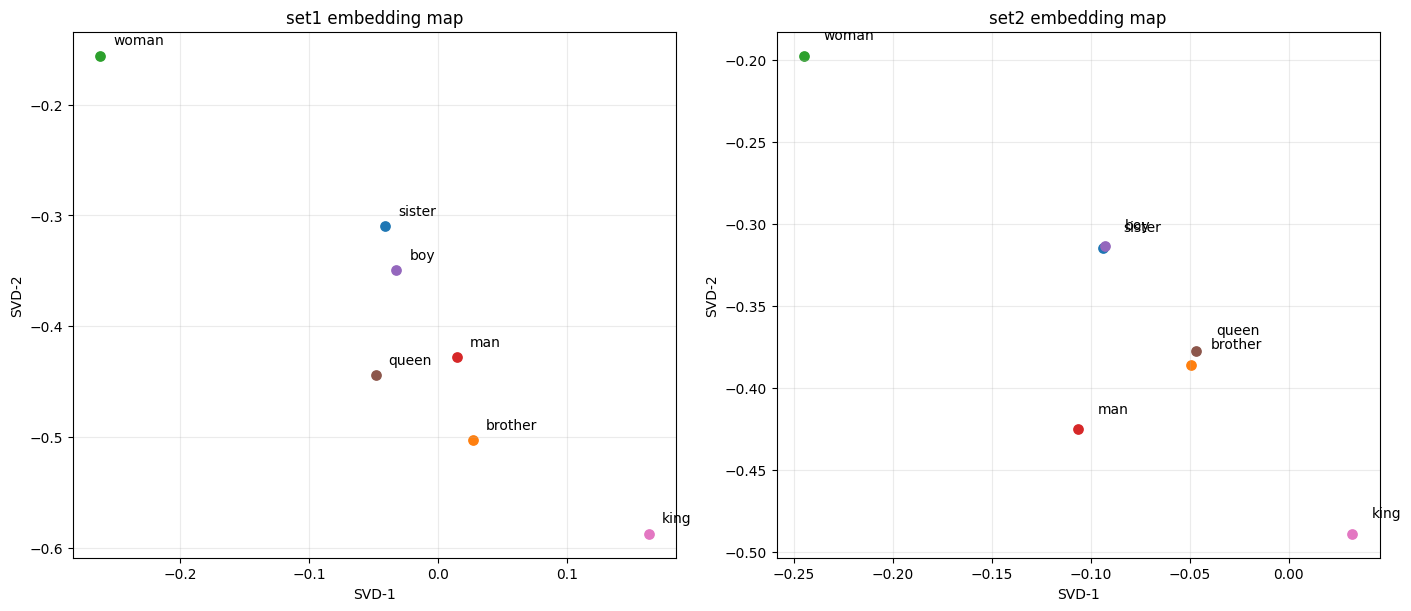

In [9]:
# Plot the following words or other words you are interested in
# You better pick those words that look different in the 2D space compared with the LSA vectors
words = ['', '', '', '', '', '', '', '']

### YOUR CODE HERE ###
words = ["sister", "brother", "woman", "man", "girl", "boy", "queen", "king"]

fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)
trial_keys = ["set1", "set2"]

for ax, trial_key in zip(axes, trial_keys):
    obj = svd_map[trial_key]
    vectors_2d = obj["vectors_2d"]
    wv = obj["wv"]

    valid_words = [w for w in words if w in wv.key_to_index]
    for w in valid_words:
        idx = wv.key_to_index[w]
        x, y = vectors_2d[idx, 0], vectors_2d[idx, 1]
        ax.scatter(x, y, s=45)
        ax.text(x + 0.01, y + 0.01, w, fontsize=10)

    ax.set_title(f"{trial_key} embedding map")
    ax.set_xlabel("SVD-1")
    ax.set_ylabel("SVD-2")
    ax.grid(alpha=0.25)

plt.show()
### END YOUR CODE ###